In [17]:
import torch
import torch.nn as nn
from PIL import Image
import cv2
import torch
import ultralytics
#ultralytics.checks()
import numpy as np
import matplotlib.pyplot as plt

In [18]:
device = torch.device("cuda" if torch.cuda.is_available()  else "cpu")

print(device)

!find . -name ".ipynb_checkpoints" -type d -exec rm -rf {} +  # .ipynb_checkpoints (automatically created by Jupyter) and labels—that do not contain files / for deleting  .ipynb_checkpoints files

cuda


In [19]:
class YOLO(nn.Module):
    def __init__(self,num_classes=3,num_anchors=3, grid_size=7):
        super(YOLO,self).__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.grid_size = grid_size

        # Backbone: Feature extractor (e.g., simplified CNN for demonstration)
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.AdaptiveAvgPool2d((7,7))
        )

        # Detection Head: Outputs bounding boxes, confidence scores, and class probabilities
        self.detector = nn.Sequential(
            nn.Conv2d(128,256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # nn.Flatten(),
            # nn.Linear(256*(grid_size//4)**2,grid_size*grid_size*(num_anchors * 5 + self.num_classes)),
            nn.Conv2d(256,num_anchors*5+num_classes,kernel_size=1)
        )
    def forward(self,x):
        #print("x  = ",x.shape)
        features = self.backbone(x)
        #print("features = ",features.shape    # torch.Size([3, 128, 7, 7])
        predictions = self.detector(features)
        predictions = predictions.permute(0,2,3,1)
        #print('predictions =  ',predictions.shape )   #  torch.Size([3, 7, 7, 18])
        return predictions        #.view(-1,self.grid_size,self.grid_size,self.num_anchors*5+self.num_classes)

# Instantiate the model
model = YOLO(num_classes=3)
print(model)

x = torch.randn(3,3,224,224)    #  [batch_size,channels,height,width]
print(model(x).shape)   # torch.Size([3, 7, 7, 18])     [batch_szie,grid_size,channels]

YOLO(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (detector): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(256, 18, kernel_size=(1, 1), stride=(1, 1))
  )
)
torch.Size([3, 7, 7, 18])


In [20]:
# here, we can configure and visualize anchor boxes for YOLO: 

import numpy as np

def generate_anchors(scales, ratios):
    """Generates anchor boxes for given scales and aspect ratios.""" 
    anchors = []
    for scale in scales:
        for ratio in ratios:
            width = scale * np.sqrt(ratio)
            height = scale / np.sqrt(ratio)
            anchors.append((width,height))
    return np.array(anchors)

# Example: Scales and ratios

scales = [0.1,0.2,0.4]
ratios = [0.5,1,2]
anchors = generate_anchors(scales, ratios)
print("Anchor Boxes:", anchors)

Anchor Boxes: [[   0.070711     0.14142]
 [        0.1         0.1]
 [    0.14142    0.070711]
 [    0.14142     0.28284]
 [        0.2         0.2]
 [    0.28284     0.14142]
 [    0.28284     0.56569]
 [        0.4         0.4]
 [    0.56569     0.28284]]


In [21]:
from torch.utils.data import Dataset 
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
from PIL import Image
from torchvision.transforms import ToTensor
import os

# Datasets 

class YOLOdataset(Dataset ):
    def __init__(self,image_dir,label_dir,transforms=None):
        self.image_dir =  image_dir
        self.label_dir =  label_dir
        self.transforms = transforms
        self.images = []
        image_dir = os.listdir(image_dir)
        for f in image_dir:
            image_path = os.path.join(self.image_dir,f )
            f2 = f[:-4]+".txt"
            label_path = os.path.join(self.label_dir,f2)
            if os.path.exists(label_path):
                
                with open(label_path,'r') as fo:
                    data = fo.read()
                if len(data)>0:
                    #print(f)
                    self.images.append(f)
    def __len__(self):
        return len(self.images)
    def __getitem__(self,idx):
        #print("idx",idx)
        image_name = self.images[idx]
        image_path = os.path.join(self.image_dir,image_name )
        label_path = os.path.join(self.label_dir,image_name .replace(".jpg",".txt"))

        # load image 
        image = Image.open( image_path ).convert('RGB')

        # LOAD BOXES 
        boxes = []

        with open(label_path,'r') as f:
            #print(label_path)
            data = f.read()
             
            #print('data = ',data)
            for line in data.split("\n"):
                #print(line,line.split())
                class_label,x,y,w,h = map(float,line.strip().split())
                boxes.append([class_label,x,y,w,h])  # we're putting everthing as a one argument

        # transform image
        if self.transforms:
            image = self.transforms(image)
            
        return image,torch.tensor(boxes)

        
import torchvision.transforms as transforms


train_transforms = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

train_dataset = YOLOdataset(image_dir="/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/train/images",
                    label_dir="/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/train/labels", transforms= train_transforms)
print(train_dataset)   
       
valid_dataset = YOLOdataset(image_dir="/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/valid/images",
                    label_dir="/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/valid/labels", transforms= transforms)
print(valid_dataset) 



In [22]:
#  Data Loader

def collate_fn(batch):

    images = []
    targets = []

    for image, boxes in batch:
        #print('image, boxes = ',  image.shape, boxes.shape)
        images.append(image)
        targets.append(boxes)
    images = torch.stack(images)  # torch.Size([4, 3, 448, 448])
    return images, targets
    
    
train_loader =  DataLoader(train_dataset,
                           batch_size =4,
                           shuffle=True,collate_fn=collate_fn)       # Essential for variable object counts)    

print(len(train_loader))

for images, targets in train_loader:
    # Move to GPU
    
    images  =  images.to(device)
    
    # 2. Move each item inside the targets list to the device
    targets = [target.to(device) for target in targets]
    
    print('images = ',images.shape)  # torch.Size([4, 3, 448, 448]) = [batch_size,channels,height,width]
    print('targets = ',len(targets))
    print( targets[0])          # tensor([[0.0000, 0.1727, 0.3859, 0.3453, 0.5703]], device='cuda:0')   [class_label,x,y,w,h]
    print(targets) 

    break


985
images =  torch.Size([4, 3, 448, 448])
targets =  4
tensor([[2.0000, 0.8016, 0.7437, 0.3969, 0.4125]], device='cuda:0')
[tensor([[2.0000, 0.8016, 0.7437, 0.3969, 0.4125]], device='cuda:0'), tensor([[0.0000, 0.6055, 0.7125, 0.7891, 0.4031]], device='cuda:0'), tensor([[1.0000, 0.3375, 0.7344, 0.0820, 0.1727],
        [2.0000, 0.4859, 0.8156, 0.1859, 0.1961]], device='cuda:0'), tensor([[1.0000, 0.4531, 0.7539, 0.9062, 0.4922]], device='cuda:0')]


In [23]:
# S = The number of grid cells per dimension
# B = The number of bounding boxes predicted per grid cell.
# C = The number of classes to predict

def encode_targets(boxes,S=7,B=3,C=3):  # B=2
    #  Encodes raw bounding boxes into YOLO-style target tensor.
    target = torch.zeros((S,S,B*5+C))    # torch.Size([7, 7, 13])  (7 , 7 ,3 * 5 + 3)  = ( 5(box) * 3(predicted bounding box) + 3 = 18 ) 
    for box in boxes:
         # box: [ class_idx , center_x, center_y, width, height]
        class_label,x,y,w,h = box
        class_label = int(class_label)
        #print('class_label = ',class_label)
        # which grid cell?
        grid_x = int(x * S)  # 
        grid_y = int(y * S)
        #print('grid_x, grid_y = ',grid_x , grid_y)

         # relative position inside cell
        x_cell = x * S - grid_x
        y_cell = y * S - grid_y
        #print('x_cell,y_cell = ',x_cell,y_cell)

        # Fill target tensor for one of the B boxes (simplified: just first one)
        target[ grid_x,grid_y,0:4] = torch.tensor([grid_x,grid_y,w,h])      # Box coordinates
        target[grid_x,grid_y, 4] = 1.0               # Object confidence mask
        #print(target[ grid_x,grid_y,0:4] )            # One-hot class label

        # one-hot class
        # By writing 5 + class_label, you bypass the first five spatial/confidence channels. Setting that index to 1 explicitly marks that specific class as present in the current grid cell
        target[grid_y, grid_x, 5 + class_label] = 1
        #print( target[grid_y, grid_x, 5 + class_label])
        
    return target
    

batch_targets = []

for boxes in targets:
    print('boxes,boxes.shape = ',boxes,boxes.shape)
    target_tensor = encode_targets(boxes)
    print('target_tensor shape =  ',target_tensor.shape)
    batch_targets.append(target_tensor)
    break
    
batch_targets = torch.stack(batch_targets) 
print('batch_targets =  ', batch_targets.shape)   # [batch_size,gridsize,channels]
print(batch_targets)

boxes,boxes.shape =  tensor([[2.0000, 0.8016, 0.7437, 0.3969, 0.4125]], device='cuda:0') torch.Size([1, 5])
target_tensor shape =   torch.Size([7, 7, 18])
batch_targets =   torch.Size([1, 7, 7, 18])
tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.

In [59]:
def yolo_loss(predictions, targets, num_classes, lambda_coord=5, lambda_noobj=0.5):
    """
    Computes YOLO loss.
    - predictions: Predicted tensor.
    - targets: Ground truth tensor.
    """
    # Unpack predictions and targets
    #print('predictions shape = ',predictions.shape)
    #print(predictions)
    #print( 'targets shape = ',targets.shape)    # torch.Size([4, 7, 7, 18]) = [batch_size,grid_size,channels]
    
    # Boxes
    pred_box1 = predictions[...,0:5]
    #print( pred_box1)
    pred_box2 = predictions[...,5:10]
    pred_box3 = predictions[...,10:15]

    # Classes
    pred_classes = predictions[..., 15:18]
    #print(' pred_classes = ',pred_classes.shape,  pred_classes)


    # Boxes
    target_box1 = targets[...,0:5]
    #print( target_box1)
    target_box2 = targets[...,5:10]
    target_box3 = targets[...,10:15]

    # Classes
    target_classes = targets[..., 15:18]
    #print('target_classes  = ',target_classes.shape , target_classes )

    # Box losses
    box_loss1 = torch.mean((pred_box1 - target_box1) ** 2)  # torch.mean adds them and then divides by the total number of elements to find the average
   
    box_loss2 = torch.mean((pred_box2 - target_box2) ** 2)

    box_loss3 = torch.mean((pred_box3 - target_box3) ** 2)

    box_loss = lambda_coord * ( box_loss1 + box_loss2 + box_loss3 )
    #print('box_loss  = ', box_loss )

    # Classification Loss
    pred_conf1 = pred_box1[...,4]
    pred_conf2 = pred_box2[...,4]
    pred_conf3 = pred_box3[...,4]

    target_conf1 = target_box1[...,4]
    target_conf2 = target_box2[...,4]
    target_conf3 = target_box3[...,4]

    # object loss 
    obj_loss1 = torch.mean((pred_conf1- target_conf1)**2)
    obj_loss2 = torch.mean((pred_conf2- target_conf2)**2)
    obj_loss3 = torch.mean((pred_conf3- target_conf3)**2)
    
    obj_loss = obj_loss1 +  obj_loss2 + obj_loss3 
    #print(' obj_loss = ',  obj_loss)

    # No-object loss
    noobj_loss = lambda_noobj * ( torch.mean((pred_conf1[target_conf1==0])**2) +       # (target_conf == 0)  = no object exists
                                   torch.mean((pred_conf2[target_conf2==0])**2) + 
                                   torch.mean((pred_conf3[target_conf3==0])**2) )  
    #print(' no obj_loss = ',   noobj_loss)
    
    # Classification Loss
    class_loss = torch.mean((pred_classes - target_classes) ** 2)
    #print('class_loss = ',class_loss )
    

    # # # Total Loss
    total_loss = box_loss + obj_loss + noobj_loss + class_loss
    
    return total_loss

    

model = YOLO(grid_size=7, num_classes=3, num_anchors=3)
model = model.to(device)
    
for images,targets in train_loader:
    images  =  images.to(device)  
    batch_targets = []
    for boxes in targets:
         target_tensor = encode_targets(boxes)
         batch_targets.append(target_tensor)
    targets = torch.stack(batch_targets) 
    targets = targets.to(device)
    predictions = model(images)
    loss = yolo_loss(predictions,targets,num_classes=3)
    print('loss = ',loss )
    break

loss =  tensor(3.4322, device='cuda:0', grad_fn=<AddBackward0>)


In [37]:
# Training loop 

import torch.optim as optim 

# Initialize model, optimizer, and loss function

model = YOLO(grid_size=7, num_classes=3, num_anchors=3)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = yolo_loss  # Your loss function from earlier

# training loop 

num_epochs =  20
for epoch in range(num_epochs):
    model.train()
    epoch_loss=0.0
    running_loss = 0.0
    best_loss = 0.0
  

    for images,targets in train_loader:
        images  =  images.to(device)
        #print(images.shape)                              # torch.Size([4, 3, 448, 448])       torch.Size([4, 7, 7, 13])
       # 2. Move each item inside the targets list to the device
        batch_targets = []
        for boxes in targets:
            #print('boxes,boxes.shape = ',boxes,boxes.shape)
            target_tensor = encode_targets(boxes)
            #print('target_tensor shape =  ',target_tensor.shape)
            batch_targets.append(target_tensor)
        targets = torch.stack(batch_targets)
        
        #print( targets.shape)
        targets = targets.to(device)
        # forward pass
        predictions = model(images)
        #print(' predictions = ',  predictions )
    # #     # loss calculation 
        loss = criterion(predictions,targets,num_classes=3)
       
    #     # backpropagation 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss+=loss.item()
        #print('epoch_loss : ',epoch_loss)
        
    train_loss =  epoch_loss / len(train_loader)    
    print(f"Epoch: {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Train_loss : {train_loss : .4f}")   
    torch.save(model.state_dict(),'/mnt/d/Python/Machine_learning/YOLO_Model/yolo_model_scratch2.pth')
    print('Model checkpoint saved')

Epoch: 1/20, Loss: 671.4551, Train_loss :  0.6817
Model checkpoint saved
Epoch: 2/20, Loss: 640.3070, Train_loss :  0.6501
Model checkpoint saved
Epoch: 3/20, Loss: 637.8808, Train_loss :  0.6476
Model checkpoint saved
Epoch: 4/20, Loss: 635.8502, Train_loss :  0.6455
Model checkpoint saved
Epoch: 5/20, Loss: 633.4770, Train_loss :  0.6431
Model checkpoint saved
Epoch: 6/20, Loss: 631.6111, Train_loss :  0.6412
Model checkpoint saved
Epoch: 7/20, Loss: 630.3661, Train_loss :  0.6400
Model checkpoint saved
Epoch: 8/20, Loss: 627.1863, Train_loss :  0.6367
Model checkpoint saved
Epoch: 9/20, Loss: 625.3369, Train_loss :  0.6349
Model checkpoint saved
Epoch: 10/20, Loss: 622.2992, Train_loss :  0.6318
Model checkpoint saved
Epoch: 11/20, Loss: 620.4367, Train_loss :  0.6299
Model checkpoint saved
Epoch: 12/20, Loss: 618.2877, Train_loss :  0.6277
Model checkpoint saved
Epoch: 13/20, Loss: 614.3524, Train_loss :  0.6237
Model checkpoint saved
Epoch: 14/20, Loss: 610.9281, Train_loss :  0.6

In [91]:
#  IOU code 

import torch

''' box format:
[x1,y1,x2,y2] =  [x_center, y_center, w, h]
'''
def calculate_iou(box1,box2):
    # intersection coordination area 
    x1 = max(box1[0],box2[0])
    y1 = max(box1[1],box2[1])
    x2 = min(box1[2],box2[2])
    y2 = min(box1[3],box2[3])

    width_inter = abs(x2 - x1)
    height_inter = abs(y2 - y1)
    area_inter =   width_inter * height_inter 
    box_area1 = ( (box1[2] - box1[0]) *
        (box1[3] - box1[1]))
    box_area2 = ( (box2[2] - box2[0]) *
        (box2[3] - box2[1]))

    area_union =  box_area1 + box_area2  - area_inter 
    
    iou =  area_inter / area_union 
    return iou 

# box1 = [2,2,6,6]  # [x1,y1,x2,y2]
# box2 = [4,4,8,8]  # [x1,y1,x2,y2]
# iou = calculate_iou(box1, box2)
# print(iou)


In [95]:
# Post-Processing: Non-Maximum Suppression (NMS)

import torch
# calculate Non Maximum Suppression  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # Move model weights to GPU

def non_max_suppression(predictions,iou_threshold=0.5): # predictions: [[x1,y1,w1,h1,score,class_id]]
    """Applies NMS to suppress overlapping boxes.""" 
    
    # Sorting by score (index 1) in descending order
    predictions =  sorted(predictions, key=lambda x: x[4], reverse=True)  # Sort highest confidence FIRST.
    print('predictions = ',predictions , len(predictions))
    final_predictions = []
    while predictions:
        best =  predictions.pop(0)  # first element = highest confidence box
        print('best[4] = ',best[4], best)
        predictions = [p for p in  predictions if calculate_iou(best[:4],p[:4]) < iou_threshold]   # best[4:] = [x1,y1,w1,h1]
        final_predictions.append(best)
        print('final_predictions = ',final_predictions, len(final_predictions))
        
    return final_predictions


# image =  Image.open('/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/train/images/egohands-public-1620850472747_png_jpg.rf.3ab344c98251337590af07c87f4f4639.jpg')

# model.eval()
# with torch.no_grad():
    
#     image_tensor = transforms.ToTensor()(image).unsqueeze(0).to('cuda')
#     predictions = model(image_tensor)
#     predictions = predictions.squeeze(0).cpu().numpy()

# # Filter boxes by confidence
# boxes = []
# for row in predictions:
#     for cell in row:

In [98]:
from PIL import Image

# Load the Model 

#   Initialize the model architecture
new_model = YOLO(num_classes=3)

# #  Load the weights (the OrderedDict) from the file
state_dict = torch.load('/mnt/d/Python/Machine_learning/YOLO_Model/yolo_model_scratch2.pth',map_location=torch.device('cuda')) # 
print(type(state_dict))

# # # 4. Load the weights into your model instance
new_model.load_state_dict(state_dict)
new_model = new_model.to(device)
print(new_model)


# inference using pre-trained models 

def perform_inference(model,image,conf_threshold):
    """Runs inference on an image and returns bounding boxes.""" 
    model.eval()
    with torch.no_grad():
        image_tensor = transforms.ToTensor()(image).unsqueeze(0).to('cuda') # ToTensor() converts: pixels 0-255 -->0-1 , (H,W,C) → (C,H,W)
        print(image_tensor.shape)
        predictions = model(image_tensor)
        print( predictions.shape)  # torch.Size([1, 7, 7, 18])
        predictions = predictions.squeeze(0).cpu().numpy()
        print(predictions.shape)

    # Filter boxes by confidence
    boxes = []
    for row in predictions:
        for cell in row:
            # # Assuming 'predictions' is your network output tensor
            #print(cell)
            # # The classes start after the bounding boxes (3 boxes * 5 values = 15)
            class_probs = cell[15:]
            class_id = np.argmax(class_probs)
            #print( class_probs ,  class_id)
            class_score = class_probs[class_id]
            #print('class probabilities ,class_score  = ', class_probs , class_score )
            # # Loop through all 3 predicted boxes for this specific cell
            
            for b in range(3):  # each box contain : [x,y,w,h,conf]
                start_idx = b * 5
                box = cell[start_idx : start_idx + 5]  # cell[0:5] , cell[5:10] , cell[10:15]
                #print(f'box_{b+1} = ', box)
                #print(box[0], box[1],box[2],box[3],box[4])
                confidence = box[4]
                final_score =  confidence   # * class_score 
                #print('final_score = ',final_score )
                if final_score >= conf_threshold:
                    boxes.append([ box[0], box[1],box[2],box[3],final_score, class_id])            #  
        print('boxes = ',boxes,len(boxes))
        
    # Apply Non-Maximum Suppression
    final_boxes = non_max_suppression(boxes)
    print('final_boxes = ',final_boxes , len(final_boxes))
    return final_boxes

          # "D:\Python\Machine_learning\YOLO_Model\rock-paper-scissors.v14i.yolov11\train\images\20220216_223142_jpg.rf.8373b5f989f33da6d0eb24a53da589e9.jpg"
image = Image.open('/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/train/images/egohands-public-1620914952708_png_jpg.rf.9011512625afc851cef4b7b158a64201.jpg')

final_boxes = perform_inference(new_model,image,conf_threshold=0.05)


<class 'collections.OrderedDict'>
YOLO(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (detector): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(256, 18, kernel_size=(1, 1), stride=(1, 1))
  )
)
torch.Size([1, 3, 640, 640])
torch.Size([1, 7, 7, 18])
(7, 7, 18)
boxes =  [] 0

[[np.float32(0.24462223), np.float32(0.18979695), np.float32(0.0222472), np.float32(0.022928989), np.float32(0.05599351), np.int64(0)]] 1


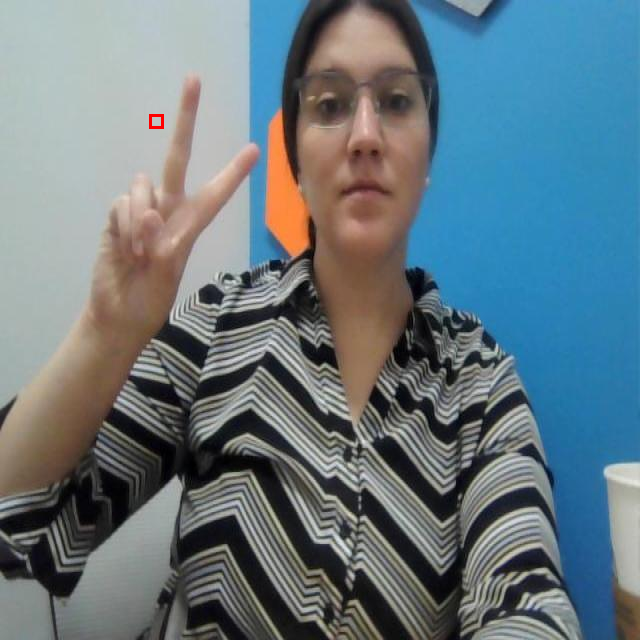

In [99]:
from PIL import ImageDraw, Image

def draw_boxes(image,boxes):
    print(boxes, len(boxes))
    #img =  Image.open(image)
    draw = ImageDraw.Draw(image)
    img_w,img_h = image.size
    for box in boxes:
        x,y,w,h,score,class_id = box   # 
        
        # Convert normalized coords to pixels
        x *= img_w
        y *= img_h
        w *= img_w
        h *= img_h

        # convert centerformat to corners 
        x1 = int(x - w/2)
        y1 = int(y - h/2)

        x2 = int(x + w/2)
        y2 =int(y + h/2)

        # draw rectangle 
        draw.rectangle([x1,y1,x2,y2], outline = 'red',width=3)

        # # draw label
        # draw.text((x1,y1), f"class{class_id}:{score:.2f}", fill='red')

    return image

    
#boxes =  [[ 0.3625, 0.6921875 ,0.41171875, 0.27265625,2]]
          # "D:\Python\Machine_learning\YOLO_Model\rock-paper-scissors.v14i.yolov11\train\images\egohands-public-1620914952708_png_jpg.rf.9011512625afc851cef4b7b158a64201.jpg"
image = Image.open('/mnt/d/Python/Machine_learning/YOLO_Model/rock-paper-scissors.v14i.yolov11/train/images/egohands-public-1620914952708_png_jpg.rf.9011512625afc851cef4b7b158a64201.jpg')

result_image = draw_boxes(image,final_boxes)
result_image.show()